# 04 - Dimension and Robustness

This notebook keeps the two cleanest late-stage synthetic analyses:

1. a homogeneous basket-dimension experiment, where only `N` changes;
2. a fixed-`N=10` robustness study over the main model drivers.

All constant-vs-regime hedge comparisons are on a common premium basis.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").is_dir()
            and (candidate / "scripts").is_dir()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the project root. Run the notebook from inside the extracted repository.")


PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / "data" / "synthetic_consolidated"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from synthetic_analysis_utils import (
    TRADING_DAYS_PER_YEAR,
    average_off_diagonal,
    basket_call_payoff,
    basket_values,
    build_transition_matrix,
    empirical_return_correlation,
    equicorrelation_matrix,
    evaluate_hedger,
    initial_hedge_from_model,
    monte_carlo_price_summary,
    pnl_summary,
    simulate_constant_paths,
    simulate_regime_switching_paths,
    summary_frame_from_results,
    unhedged_short_pnl,
)

In [2]:
rate = 0.03
maturity = 1.0
start_regime = 0
bump_fraction = 0.01

rho_constant_level = 0.35
rho_calm_level = 0.20
rho_stress_level = 0.98
stress_share_target = 0.40
lambda_daily = 0.08

n_assets_grid = [2, 3, 4, 5, 6, 8, 10]
hedge_steps = 12
n_true_world_paths = 100
delta_mc_paths = 1000
initial_price_mc_paths = 10000
repeat_count = 5
spot_level = 100.0
vol_level = 0.22

transition_daily = build_transition_matrix(
    stress_share_target * lambda_daily,
    (1.0 - stress_share_target) * lambda_daily,
)
transition_hedge = np.linalg.matrix_power(transition_daily, TRADING_DAYS_PER_YEAR // hedge_steps)

In [3]:
def build_homogeneous_pricing_inputs(n_assets, strike_multiplier=1.0, hedge_steps_value=hedge_steps, rho_stress_value=rho_stress_level, stress_share_value=stress_share_target, lambda_value=lambda_daily):
    spot = np.full(n_assets, spot_level)
    vol = np.full(n_assets, vol_level)
    weights = np.full(n_assets, 1.0 / n_assets)
    div_yield = np.zeros(n_assets)
    strike = strike_multiplier * float(weights @ spot)
    transition_daily = build_transition_matrix(stress_share_value * lambda_value, (1.0 - stress_share_value) * lambda_value)
    transition_hedge = np.linalg.matrix_power(transition_daily, TRADING_DAYS_PER_YEAR // hedge_steps_value)
    return {
        "spot": spot,
        "weights": weights,
        "strike": strike,
        "rate": rate,
        "div_yield": div_yield,
        "vol": vol,
        "maturity": maturity,
        "hedge_steps": hedge_steps_value,
        "hedge_dt": maturity / hedge_steps_value,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "chol_constant": np.linalg.cholesky(equicorrelation_matrix(n_assets, rho_constant_level)),
        "chol_calm": np.linalg.cholesky(equicorrelation_matrix(n_assets, rho_calm_level)),
        "chol_stress": np.linalg.cholesky(equicorrelation_matrix(n_assets, rho_stress_value)),
        "transition_hedge": transition_hedge,
        "start_regime": start_regime,
    }


def run_homogeneous_dimension_scenario(n_assets, repeat_id, scenario_seed):
    pricing_inputs = build_homogeneous_pricing_inputs(n_assets)
    true_paths, true_regimes = simulate_regime_switching_paths(
        spot=pricing_inputs["spot"],
        rate=rate,
        div_yield=pricing_inputs["div_yield"],
        vol=pricing_inputs["vol"],
        maturity=maturity,
        n_steps=pricing_inputs["hedge_steps"],
        n_paths=n_true_world_paths,
        corr_calm=pricing_inputs["chol_calm"] @ pricing_inputs["chol_calm"].T,
        corr_stress=pricing_inputs["chol_stress"] @ pricing_inputs["chol_stress"].T,
        transition_matrix=pricing_inputs["transition_hedge"],
        start_regime=start_regime,
        seed=scenario_seed,
    )
    constant_seed = scenario_seed + 1000
    regime_seed = scenario_seed + 2000
    constant_initial_state = initial_hedge_from_model("constant", pricing_inputs, constant_seed)
    regime_initial_state = initial_hedge_from_model("regime", pricing_inputs, regime_seed)
    reference_price = regime_initial_state[0]
    hedger_initial_states = {"constant": constant_initial_state, "regime": regime_initial_state}

    rows = []
    for hedger_idx, hedger in enumerate(["constant", "regime"]):
        summary, _, _ = evaluate_hedger(
            true_paths=true_paths,
            true_regimes=true_regimes,
            hedge_model=hedger,
            pricing_inputs=pricing_inputs,
            base_seed=scenario_seed + 1000 * (hedger_idx + 1),
            funding_price=reference_price,
            precomputed_initial=hedger_initial_states[hedger],
        )
        rows.append(
            {
                "n_assets": n_assets,
                "repeat_id": repeat_id,
                "hedger": hedger,
                "avg_stress_fraction": float(true_regimes.mean()),
                **summary,
            }
        )
    return pd.DataFrame(rows)


homogeneous_rows = []
for n_assets in n_assets_grid:
    for repeat_id in range(repeat_count):
        scenario_seed = 220000 + 11000 * n_assets + 400 * repeat_id
        homogeneous_rows.append(run_homogeneous_dimension_scenario(n_assets, repeat_id, scenario_seed))

homogeneous_raw = pd.concat(homogeneous_rows, ignore_index=True)
homogeneous_summary = (
    homogeneous_raw.groupby(["n_assets", "hedger"], as_index=False)
    .agg(
        avg_model_initial_price=("model_initial_price", "mean"),
        avg_mean_pnl=("mean_pnl", "mean"),
        avg_std_pnl=("std_pnl", "mean"),
        avg_q05_pnl=("q05_pnl", "mean"),
        avg_q01_pnl=("q01_pnl", "mean"),
        avg_runtime_seconds=("runtime_seconds", "mean"),
        avg_stress_fraction=("avg_stress_fraction", "mean"),
    )
)
homogeneous_gap = homogeneous_summary.pivot(
    index="n_assets",
    columns="hedger",
    values=["avg_model_initial_price", "avg_std_pnl", "avg_q05_pnl", "avg_q01_pnl", "avg_mean_pnl", "avg_runtime_seconds"],
)
homogeneous_gap.columns = ["_".join(col).strip() for col in homogeneous_gap.columns.to_flat_index()]
homogeneous_gap = homogeneous_gap.reset_index()
homogeneous_gap["regime_price_minus_constant"] = homogeneous_gap["avg_model_initial_price_regime"] - homogeneous_gap["avg_model_initial_price_constant"]
homogeneous_gap["std_gap_constant_minus_regime"] = homogeneous_gap["avg_std_pnl_constant"] - homogeneous_gap["avg_std_pnl_regime"]
homogeneous_gap["q05_gap_regime_minus_constant"] = homogeneous_gap["avg_q05_pnl_regime"] - homogeneous_gap["avg_q05_pnl_constant"]
homogeneous_gap["q01_gap_regime_minus_constant"] = homogeneous_gap["avg_q01_pnl_regime"] - homogeneous_gap["avg_q01_pnl_constant"]
homogeneous_gap["mean_gap_regime_minus_constant"] = homogeneous_gap["avg_mean_pnl_regime"] - homogeneous_gap["avg_mean_pnl_constant"]

homogeneous_raw.to_csv(ANALYSIS_DIR / "dimension_homogeneous_raw.csv", index=False)
homogeneous_summary.to_csv(ANALYSIS_DIR / "dimension_homogeneous_summary.csv", index=False)
homogeneous_gap.to_csv(ANALYSIS_DIR / "dimension_homogeneous_gap_clean.csv", index=False)

display(Markdown("## Homogeneous dimension scaling"))
display(homogeneous_gap.round(4))

## Homogeneous dimension scaling

,n_assets,avg_model_initial_price_constant,avg_model_initial_price_regime,avg_std_pnl_constant,avg_std_pnl_regime,avg_q05_pnl_constant,avg_q05_pnl_regime,avg_q01_pnl_constant,avg_q01_pnl_regime,avg_mean_pnl_constant,avg_mean_pnl_regime,avg_runtime_seconds_constant,avg_runtime_seconds_regime,regime_price_minus_constant,std_gap_constant_minus_regime,q05_gap_regime_minus_constant,q01_gap_regime_minus_constant,mean_gap_regime_minus_constant
0,2,8.7387,9.0033,1.9121,1.9027,-3.3561,-3.2096,-4.8578,-4.8015,0.0079,-0.0105,0.2276,0.5664,0.2647,0.0094,0.1465,0.0562,-0.0183
1,3,8.1099,8.5890,1.9735,1.9228,-3.2917,-2.9373,-5.1866,-4.5845,-0.0062,0.0093,0.2298,0.6314,0.4791,0.0507,0.3544,0.6022,0.0155
2,4,7.8261,8.3074,1.8952,1.8644,-3.4546,-3.3030,-5.8689,-5.0965,0.0171,0.0438,0.3098,0.7701,0.4813,0.0308,0.1516,0.7725,0.0267
3,5,7.5270,8.1221,1.7677,1.7975,-2.9204,-3.2654,-4.9619,-4.5159,0.1105,0.0393,0.2671,0.8790,0.5951,-0.0298,-0.3450,0.4460,-0.0712
4,6,7.4095,8.0514,1.9752,1.9553,-3.2799,-3.0658,-5.6591,-5.0710,0.1190,0.0995,0.3022,0.9329,0.6420,0.0199,0.2141,0.5882,-0.0195
5,8,7.2841,7.9742,1.9297,1.8739,-3.5534,-3.2852,-6.0109,-5.2108,0.0346,0.0428,0.4108,1.1160,0.6901,0.0558,0.2682,0.8000,0.0082
6,10,7.2482,7.9436,1.9658,1.9276,-3.4665,-3.4210,-5.8751,-5.0232,0.0012,-0.0276,1.6030,3.7252,0.6955,0.0383,0.0455,0.8520,-0.0287


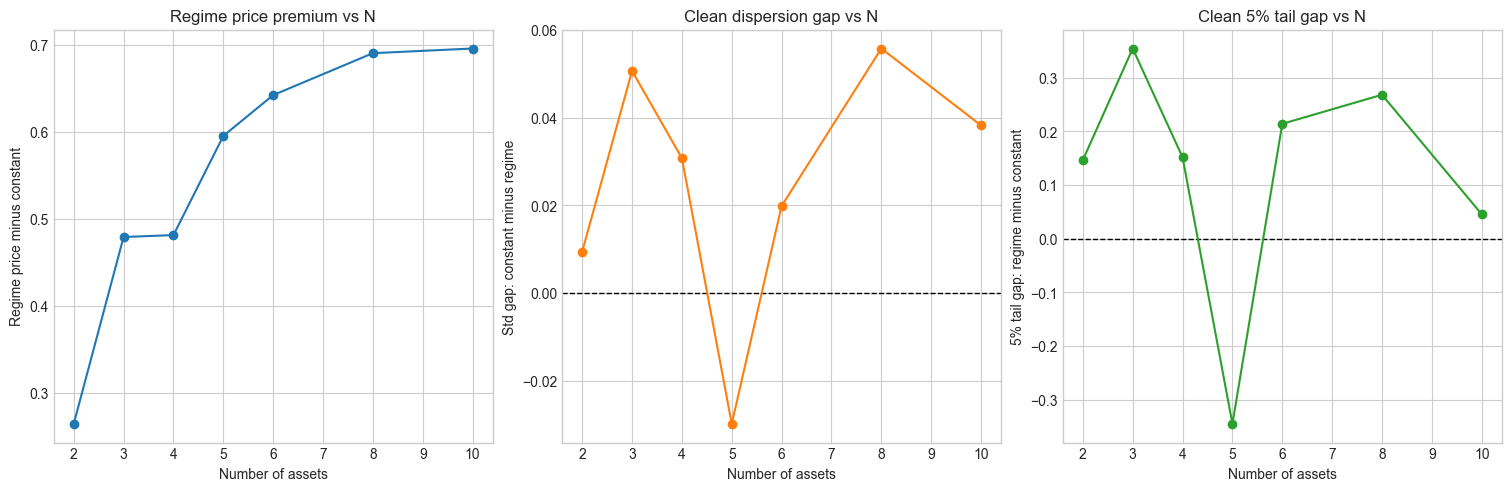

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

axes[0].plot(homogeneous_gap["n_assets"], homogeneous_gap["regime_price_minus_constant"], marker="o")
axes[0].set_title("Regime price premium vs N")
axes[0].set_xlabel("Number of assets")
axes[0].set_ylabel("Regime price minus constant")

axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[1].plot(homogeneous_gap["n_assets"], homogeneous_gap["std_gap_constant_minus_regime"], marker="o", color="tab:orange")
axes[1].set_title("Clean dispersion gap vs N")
axes[1].set_xlabel("Number of assets")
axes[1].set_ylabel("Std gap: constant minus regime")

axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[2].plot(homogeneous_gap["n_assets"], homogeneous_gap["q05_gap_regime_minus_constant"], marker="o", color="tab:green")
axes[2].set_title("Clean 5% tail gap vs N")
axes[2].set_xlabel("Number of assets")
axes[2].set_ylabel("5% tail gap: regime minus constant")
plt.show()

In [5]:
N = 10
scenario_catalog = []

def add_scenario(group, value, *, rho_stress, stress_share, lambda_daily_value, hedge_steps_value, strike_multiplier):
    scenario_catalog.append(
        {
            "scenario_group": group,
            "scenario_value": value,
            "rho_stress": rho_stress,
            "stress_share": stress_share,
            "lambda_daily": lambda_daily_value,
            "hedge_steps": hedge_steps_value,
            "strike_multiplier": strike_multiplier,
        }
    )

add_scenario("baseline", "baseline", rho_stress=0.98, stress_share=0.40, lambda_daily_value=0.08, hedge_steps_value=12, strike_multiplier=1.0)
for value in [0.75, 0.90, 0.98]:
    add_scenario("stress_corr", str(value), rho_stress=value, stress_share=0.40, lambda_daily_value=0.08, hedge_steps_value=12, strike_multiplier=1.0)
for value in [0.20, 0.30, 0.40, 0.50]:
    add_scenario("stress_share", str(value), rho_stress=0.98, stress_share=value, lambda_daily_value=0.08, hedge_steps_value=12, strike_multiplier=1.0)
for label, steps in [("Monthly", 12), ("Quarterly", 4), ("Semiannual", 2)]:
    add_scenario("hedge_frequency", label, rho_stress=0.98, stress_share=0.40, lambda_daily_value=0.08, hedge_steps_value=steps, strike_multiplier=1.0)
for value in [0.95, 1.00, 1.05]:
    add_scenario("strike_multiplier", str(value), rho_stress=0.98, stress_share=0.40, lambda_daily_value=0.08, hedge_steps_value=12, strike_multiplier=value)

parameter_rows = []
n_true_world_paths_parameter = 80
delta_mc_paths_parameter = 800
initial_price_mc_paths_parameter = 8000
repeat_count_parameter = 4

for scenario_idx, scenario in enumerate(scenario_catalog, start=1):
    pricing_inputs = build_homogeneous_pricing_inputs(
        n_assets=N,
        strike_multiplier=scenario["strike_multiplier"],
        hedge_steps_value=scenario["hedge_steps"],
        rho_stress_value=scenario["rho_stress"],
        stress_share_value=scenario["stress_share"],
        lambda_value=scenario["lambda_daily"],
    )
    pricing_inputs["delta_mc_paths"] = delta_mc_paths_parameter
    pricing_inputs["initial_price_mc_paths"] = initial_price_mc_paths_parameter

    for repeat_id in range(repeat_count_parameter):
        scenario_seed = 310000 + 8000 * scenario_idx + 200 * repeat_id
        true_paths, true_regimes = simulate_regime_switching_paths(
            spot=pricing_inputs["spot"],
            rate=rate,
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            maturity=maturity,
            n_steps=pricing_inputs["hedge_steps"],
            n_paths=n_true_world_paths_parameter,
            corr_calm=pricing_inputs["chol_calm"] @ pricing_inputs["chol_calm"].T,
            corr_stress=pricing_inputs["chol_stress"] @ pricing_inputs["chol_stress"].T,
            transition_matrix=pricing_inputs["transition_hedge"],
            start_regime=start_regime,
            seed=scenario_seed,
        )
        constant_seed = scenario_seed + 1000
        regime_seed = scenario_seed + 2000
        constant_initial_state = initial_hedge_from_model("constant", pricing_inputs, constant_seed)
        regime_initial_state = initial_hedge_from_model("regime", pricing_inputs, regime_seed)
        reference_price = regime_initial_state[0]
        hedger_initial_states = {"constant": constant_initial_state, "regime": regime_initial_state}

        for hedger_idx, hedger in enumerate(["constant", "regime"]):
            summary, _, _ = evaluate_hedger(
                true_paths=true_paths,
                true_regimes=true_regimes,
                hedge_model=hedger,
                pricing_inputs=pricing_inputs,
                base_seed=scenario_seed + 1000 * (hedger_idx + 1),
                funding_price=reference_price,
                precomputed_initial=hedger_initial_states[hedger],
            )
            parameter_rows.append(
                {
                    "scenario_group": scenario["scenario_group"],
                    "scenario_value": scenario["scenario_value"],
                    "repeat_id": repeat_id,
                    "hedger": hedger,
                    "rho_stress": scenario["rho_stress"],
                    "stress_share": scenario["stress_share"],
                    "lambda_daily": scenario["lambda_daily"],
                    "hedge_steps": scenario["hedge_steps"],
                    "strike_multiplier": scenario["strike_multiplier"],
                    "avg_stress_fraction": float(true_regimes.mean()),
                    **summary,
                }
            )

parameter_raw = pd.DataFrame(parameter_rows)
parameter_summary = (
    parameter_raw.groupby(["scenario_group", "scenario_value", "hedger"], as_index=False)
    .agg(
        avg_model_initial_price=("model_initial_price", "mean"),
        avg_mean_pnl=("mean_pnl", "mean"),
        avg_std_pnl=("std_pnl", "mean"),
        avg_q05_pnl=("q05_pnl", "mean"),
        avg_q01_pnl=("q01_pnl", "mean"),
        avg_runtime_seconds=("runtime_seconds", "mean"),
        rho_stress=("rho_stress", "mean"),
        stress_share=("stress_share", "mean"),
        lambda_daily=("lambda_daily", "mean"),
        hedge_steps=("hedge_steps", "mean"),
        strike_multiplier=("strike_multiplier", "mean"),
        avg_stress_fraction=("avg_stress_fraction", "mean"),
    )
)
parameter_gap = parameter_summary.pivot(
    index=["scenario_group", "scenario_value"],
    columns="hedger",
    values=["avg_model_initial_price", "avg_std_pnl", "avg_q05_pnl", "avg_q01_pnl", "avg_mean_pnl"],
)
parameter_gap.columns = ["_".join(col).strip() for col in parameter_gap.columns.to_flat_index()]
parameter_gap = parameter_gap.reset_index()
parameter_gap["regime_price_minus_constant"] = parameter_gap["avg_model_initial_price_regime"] - parameter_gap["avg_model_initial_price_constant"]
parameter_gap["std_gap_constant_minus_regime"] = parameter_gap["avg_std_pnl_constant"] - parameter_gap["avg_std_pnl_regime"]
parameter_gap["q05_gap_regime_minus_constant"] = parameter_gap["avg_q05_pnl_regime"] - parameter_gap["avg_q05_pnl_constant"]
parameter_gap["q01_gap_regime_minus_constant"] = parameter_gap["avg_q01_pnl_regime"] - parameter_gap["avg_q01_pnl_constant"]
parameter_gap["mean_gap_regime_minus_constant"] = parameter_gap["avg_mean_pnl_regime"] - parameter_gap["avg_mean_pnl_constant"]

pd.DataFrame(scenario_catalog).to_csv(ANALYSIS_DIR / "n10_parameter_scenarios.csv", index=False)
parameter_raw.to_csv(ANALYSIS_DIR / "n10_parameter_raw.csv", index=False)
parameter_summary.to_csv(ANALYSIS_DIR / "n10_parameter_summary.csv", index=False)
parameter_gap.to_csv(ANALYSIS_DIR / "n10_parameter_gap_clean.csv", index=False)

display(Markdown("## Fixed N=10 robustness"))
display(parameter_gap.round(4))

## Fixed N=10 robustness

,scenario_group,scenario_value,avg_model_initial_price_constant,avg_model_initial_price_regime,avg_std_pnl_constant,avg_std_pnl_regime,avg_q05_pnl_constant,avg_q05_pnl_regime,avg_q01_pnl_constant,avg_q01_pnl_regime,avg_mean_pnl_constant,avg_mean_pnl_regime,regime_price_minus_constant,std_gap_constant_minus_regime,q05_gap_regime_minus_constant,q01_gap_regime_minus_constant,mean_gap_regime_minus_constant
0,baseline,baseline,7.1063,7.8350,1.9526,1.9578,-2.9336,-3.1332,-5.3011,-4.9546,-0.0189,-0.0268,0.7287,-0.0052,-0.1995,0.3465,-0.0079
1,hedge_frequency,Monthly,7.1938,7.9184,2.1248,2.0136,-4.2455,-3.6169,-5.7120,-5.2831,-0.1018,-0.0683,0.7245,0.1112,0.6286,0.4290,0.0335
2,hedge_frequency,Quarterly,7.0916,7.7125,2.8120,2.8410,-5.1044,-5.7473,-8.1916,-8.0858,-0.0183,-0.1084,0.6208,-0.0290,-0.6429,0.1058,-0.0901
3,hedge_frequency,Semiannual,7.2282,7.1042,3.5107,3.4361,-5.8989,-5.8600,-10.1869,-9.3688,0.1548,0.1428,-0.1240,0.0746,0.0389,0.8181,-0.0120
4,stress_corr,0.75,7.1705,7.4739,1.9019,1.8548,-3.6328,-3.2550,-4.8300,-4.4025,-0.0044,0.0225,0.3034,0.0471,0.3778,0.4275,0.0268
5,stress_corr,0.9,7.3247,7.6839,1.9308,1.8836,-3.4368,-3.4270,-5.6929,-4.9810,-0.1089,-0.1278,0.3592,0.0472,0.0098,0.7119,-0.0189
6,stress_corr,0.98,7.1206,7.9583,1.9271,1.8944,-3.1787,-3.1746,-5.3222,-4.9825,0.0226,0.0105,0.8377,0.0327,0.0041,0.3397,-0.0121
7,stress_share,0.2,7.1583,7.0484,1.5655,1.6047,-2.2796,-2.6104,-3.6414,-3.6982,0.1928,0.1804,-0.1099,-0.0392,-0.3309,-0.0568,-0.0124
8,stress_share,0.3,7.1433,7.5314,1.7688,1.7574,-2.8100,-2.6185,-4.4730,-4.2335,0.1105,0.0904,0.3881,0.0114,0.1915,0.2395,-0.0201
9,stress_share,0.4,7.1459,7.8320,1.8875,1.8808,-3.0774,-3.1814,-5.0752,-4.8497,0.1686,0.1160,0.6861,0.0067,-0.1040,0.2256,-0.0525


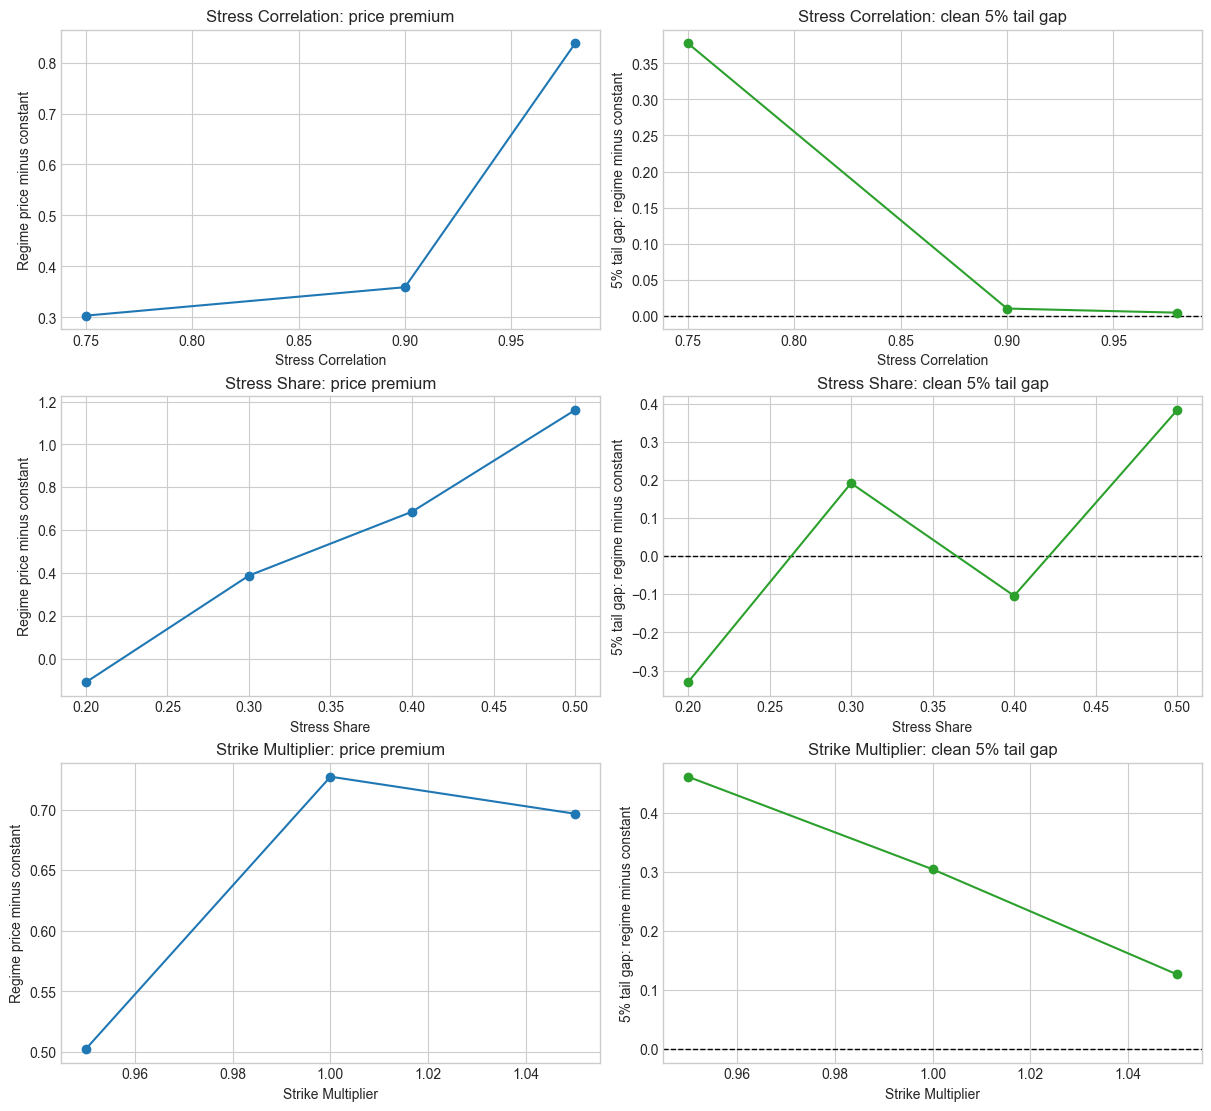

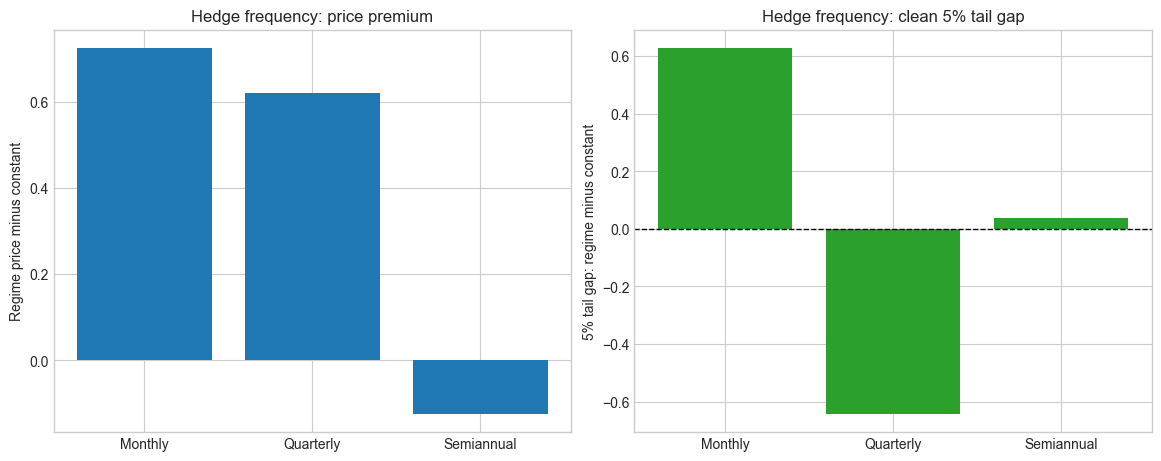

In [6]:
numeric_groups = {
    "stress_corr": "Stress Correlation",
    "stress_share": "Stress Share",
    "strike_multiplier": "Strike Multiplier",
}

fig, axes = plt.subplots(len(numeric_groups), 2, figsize=(12, 11), constrained_layout=True)
for row_idx, (group, title) in enumerate(numeric_groups.items()):
    frame = parameter_gap[parameter_gap["scenario_group"] == group].copy()
    frame["x_value"] = frame["scenario_value"].astype(float)
    frame = frame.sort_values("x_value")

    axes[row_idx, 0].plot(frame["x_value"], frame["regime_price_minus_constant"], marker="o")
    axes[row_idx, 0].set_title(f"{title}: price premium")
    axes[row_idx, 0].set_xlabel(title)
    axes[row_idx, 0].set_ylabel("Regime price minus constant")

    axes[row_idx, 1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
    axes[row_idx, 1].plot(frame["x_value"], frame["q05_gap_regime_minus_constant"], marker="o", color="tab:green")
    axes[row_idx, 1].set_title(f"{title}: clean 5% tail gap")
    axes[row_idx, 1].set_xlabel(title)
    axes[row_idx, 1].set_ylabel("5% tail gap: regime minus constant")

plt.show()

hedge_frame = parameter_gap[parameter_gap["scenario_group"] == "hedge_frequency"].copy()
hedge_frame["scenario_value"] = pd.Categorical(
    hedge_frame["scenario_value"],
    categories=["Monthly", "Quarterly", "Semiannual"],
    ordered=True,
)
hedge_frame = hedge_frame.sort_values("scenario_value")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)
axes[0].bar(hedge_frame["scenario_value"], hedge_frame["regime_price_minus_constant"], color="tab:blue")
axes[0].set_title("Hedge frequency: price premium")
axes[0].set_ylabel("Regime price minus constant")

axes[1].bar(hedge_frame["scenario_value"], hedge_frame["q05_gap_regime_minus_constant"], color="tab:green")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_title("Hedge frequency: clean 5% tail gap")
axes[1].set_ylabel("5% tail gap: regime minus constant")
plt.show()

## Takeaway

The dimension and robustness notebook now uses the cleaner late-stage experiments only:

- the homogeneous `N` study isolates basket dimension without changing the marginal inputs;
- the fixed-`N=10` study focuses on the strongest model drivers instead of every exploratory parameter branch;
- the hedge comparisons use a common premium basis, so the reported tail gaps are less contaminated by initial price differences.